<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/Conditional_Autoencoder_for_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

IMG_SIZE = 32
LATENT_DIM = 128
N_CLASSES = 10
LABEL_EMB_DIM = 16
BATCH_SIZE = 128
EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(testset, batch_size=10, shuffle=True)


In [14]:
class ConditionalEncoder(nn.Module):
    def __init__(self, latent_dim, n_classes, label_emb_dim):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, label_emb_dim)
        self.conv = nn.Sequential(
            nn.Conv2d(3 + label_emb_dim, 64, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1), nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(256 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256), nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

    def forward(self, x, labels):
        label_emb = self.label_emb(labels)
        label_map = label_emb.unsqueeze(2).unsqueeze(3).expand(-1, -1, IMG_SIZE, IMG_SIZE)
        x = torch.cat([x, label_map], dim=1)
        x = self.conv(x)
        x = self.flatten(x)
        z = self.fc(x)
        return z

class ConditionalDecoder(nn.Module):
    def __init__(self, latent_dim, n_classes, label_emb_dim):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, label_emb_dim)
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + label_emb_dim, 256), nn.ReLU(),
            nn.Linear(256, 256 * (IMG_SIZE // 8) * (IMG_SIZE // 8)), nn.ReLU()
        )
        self.unflatten = nn.Unflatten(1, (256, IMG_SIZE // 8, IMG_SIZE // 8))
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, z, labels):
        label_emb = self.label_emb(labels)
        z_cond = torch.cat([z, label_emb], dim=1)
        x = self.fc(z_cond)
        x = self.unflatten(x)
        x = self.deconv(x)
        return x

encoder = ConditionalEncoder(LATENT_DIM, N_CLASSES, LABEL_EMB_DIM).to(DEVICE)
decoder = ConditionalDecoder(LATENT_DIM, N_CLASSES, LABEL_EMB_DIM).to(DEVICE)


In [15]:
autoencoder_params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(autoencoder_params, lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(EPOCHS):
    encoder.train()
    decoder.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        z = encoder(imgs, labels)
        recons = decoder(z, labels)
        loss = criterion(recons, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")


Epoch 1/30 - Loss: 0.0286
Epoch 2/30 - Loss: 0.0175
Epoch 3/30 - Loss: 0.0139
Epoch 4/30 - Loss: 0.0124
Epoch 5/30 - Loss: 0.0116
Epoch 6/30 - Loss: 0.0109
Epoch 7/30 - Loss: 0.0102
Epoch 8/30 - Loss: 0.0098
Epoch 9/30 - Loss: 0.0094
Epoch 10/30 - Loss: 0.0090
Epoch 11/30 - Loss: 0.0087
Epoch 12/30 - Loss: 0.0085
Epoch 13/30 - Loss: 0.0083
Epoch 14/30 - Loss: 0.0081
Epoch 15/30 - Loss: 0.0080
Epoch 16/30 - Loss: 0.0079
Epoch 17/30 - Loss: 0.0077
Epoch 18/30 - Loss: 0.0076
Epoch 19/30 - Loss: 0.0075
Epoch 20/30 - Loss: 0.0074
Epoch 21/30 - Loss: 0.0073
Epoch 22/30 - Loss: 0.0072
Epoch 23/30 - Loss: 0.0071
Epoch 24/30 - Loss: 0.0070
Epoch 25/30 - Loss: 0.0070
Epoch 26/30 - Loss: 0.0070
Epoch 27/30 - Loss: 0.0069
Epoch 28/30 - Loss: 0.0068
Epoch 29/30 - Loss: 0.0068
Epoch 30/30 - Loss: 0.0067


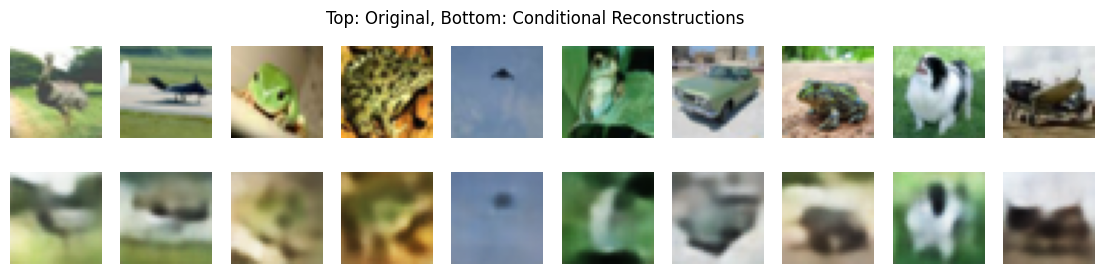

In [16]:
encoder.eval()
decoder.eval()
imgs, labels = next(iter(test_loader))
imgs = imgs.to(DEVICE)
labels = labels.to(DEVICE)
with torch.no_grad():
    z = encoder(imgs, labels)
    recons = decoder(z, labels).cpu()
imgs = imgs.cpu()

plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(imgs[i].permute(1,2,0).numpy())
    plt.axis('off')
    plt.subplot(2, 10, 10+i+1)
    plt.imshow(recons[i].permute(1,2,0).numpy())
    plt.axis('off')
plt.suptitle("Top: Original, Bottom: Conditional Reconstructions")
plt.show()
